# **Interpolazione polinomiale**

Lo scopo delle tecniche di interpolazione è quello di ricavare, in forma chiusa, una relazione del tipo $y=p(x)$ che catturi alcune coppie di punti $(x_{1},y_{1}),\dots,(x_{n}, y_{n})$. Tipicamente, questo problema risulta di interesse in due contesti:

*   Approssimazione di funzioni: si vuole approssimare una funzione $f$ nota con un'espressione più semplice, ad esempio in vista del calcolo numerico (si veda calcolo di integrali!).
*   Approssimazione di dati: si vuole ricostruire l'andamento di alcuni dati (ad esempio provenienti da osservazioni sperimentali, oppure dal campionamento di una funzione $f$ non nota).

Strettamente parlando, si parla di *interpolazione* se a partire dai punti viene proposta una funzione $\tilde{p}$ che passa **esattamente** dai dati sperimentali, cioè
</br></br>
\begin{equation*}y_{i}=\tilde{p}(x_{i})\quad\quad\forall i = 1,\dots, n
\end{equation*}
</br>
Si parla invece di _approssimazione ai minimi quadrati_ se l'obiettivo è quello di trovare una funzione $\hat{p}$ che minimizzi lo scarto quadratico
</br></br>
\begin{equation*}
\sum_{i=1}^{n}|y_{i}-\hat{p}(x_{i})|^{2}
\end{equation*}
</br>
all'interno di una "classe di possibili funzioni".

Oggi ci focalizzaremo su tre tipologie di interpolazione e approssimazione:

  1. Interpolazione polinomiale di Lagrange, dove $\tilde{p}$ è un polinomio di grado $n-1$
  2. Interpolazione composita (spline), dove $\tilde{p}$ è un polinomio di grado $k$ _a tratti_ (es: spezzata/spline cubica)
  3. Approssimazione polinomiale (minimi quadrati), dove $\hat{p}$ è un polinomio di grado $k<n-1$.


In [108]:
import numpy as np
import matplotlib.pyplot as plt

## **Esercizio 1: Interpolazione per l'approssimazione di funzioni**

L'interpolazione polinomiale può essere utilizzata per approssimare una data funzione $f: [a,b]\to\mathbb{R}$. In questo caso, si valuta $f$ su di una griglia con $n+1$ nodi, $\{x_{0},\dots,x_{n}\}\subset[a,b]$ e la si approssima con l'interpolante $\tilde{p}=\Pi_{n}f$ passante per i nodi $\{(x_{i}, f(x_{i}))\}_{i=0}^{n}$.
La notazione $\Pi_{n}f$ sta ad enfatizzare che l'interpolante dipende dalla funzione $f$ e dal numero di intervalli della partizione $n$.
</br></br>
La qualità dell'approssimazione può essere indagata a posteriori valutando l'errore globale
</br></br>
\begin{equation*}
E_{n}:=\max_{x\in[a,b]}|f(x)-\Pi_{n}f(x)|
\end{equation*}
</br>
sull'intervallo $[a,b]$. Come vedremo, nel caso di interpolazione polinomiale di Lagrange, la numerosità dei nodi non basta a garantire una buona approssimazione: occorre anche posizionare i nodi in modo opportuno!

<mark>**Esercizio 1.1**</mark></br>
Si consideri la funzione (chiamata **funzione di Runge**)
</br></br>
\begin{equation*}
f(x)=\frac{1}{1+x^{2}},
\end{equation*}
</br>
sull'intervallo $[a,b]=[-5,5]$. Si discuta la possibilità di interpolare $f(x)$ tramite polinomi di Lagrange. Questo può essere fatto utilizzando le funzioni **polyfit** e **polyval** della libreria **numpy**.

Si cominci rappresentando la funzione $f(x)$ e le funzioni della base di Lagrange $\mathcal{L}_i (x), i=0,...,n$. Si consideri un polinomio di interpolazione di grado 3.

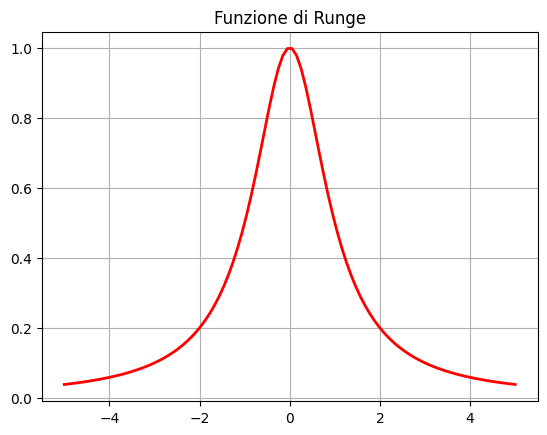

In [109]:
# Definizione di f (tramite lambda function)
f = lambda x: 1.0/(1+x**2)

# Creazione dell'intervallo di punti
a = -5
b = 5
x_grid = np.linspace(a, b, 100)

# Rappresentazione di f
plt.figure()
plt.plot(x_grid, f(x_grid), 'r-', linewidth=2)
plt.title("Funzione di Runge")
plt.grid()
plt.show()

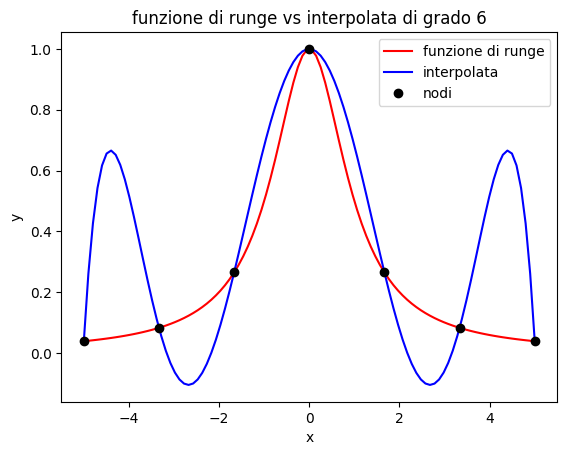

In [110]:
from numpy import polyfit, polyval

#Esempio di interpolazione polinomiale di Lagrange con grado n=4 usando n+1 nodi equispaziati sull'intervallo [a,b].
deg=6
x_nodi=np.linspace(a,b,deg+1)
y_nodi=f(x_nodi)
p=polyfit(x_nodi,y_nodi,deg)
interpolata = lambda x: polyval(p,x)
plt.figure()
plt.plot(x_grid,f(x_grid),'r')
plt.plot(x_grid,interpolata(x_grid),'b')
plt.plot(x_nodi,y_nodi,'ok')
plt.xlabel("x")
plt.ylabel("y")
plt.title("funzione di runge vs interpolata di grado %d" % deg)
plt.legend(["funzione di runge", "interpolata" ,"nodi"])
plt.show()

Vediamo meglio cosa si nasconde dietro i comandi polyfit e polyval...

L'interpolante polinomiale di Lagrange di grado $n$ passante per $(x_i, y_i)$ con $i=0,...,n$ è definita come:

\begin{equation}
p_n(x) = \sum_{i=0}^{n} y_i \mathcal{L}_i(x),
\end{equation}

dove $\mathcal{L}_i$ costituiscono la base di Lagrange.

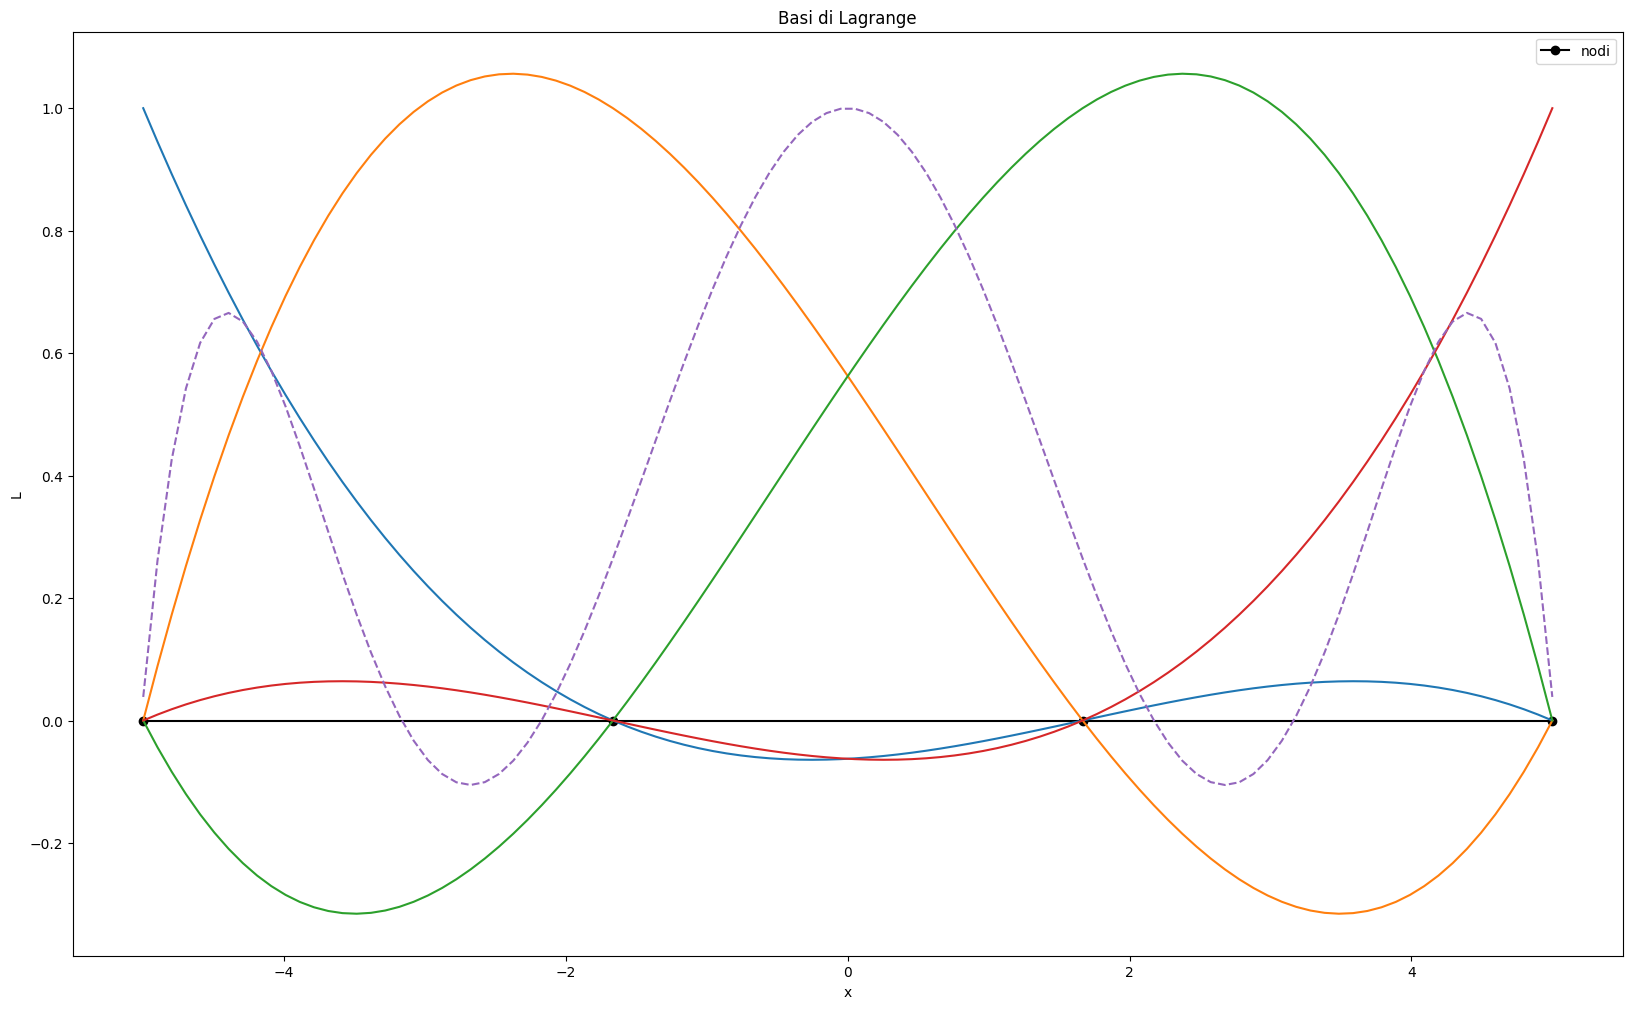

In [111]:
# Esempio della costruzione della base di Lagrange con grado n=3 usando n+1 nodi equispaziati sull'intervallo [a,b].

# grado del polinomio
deg=3
# estremi dell'intervallo
a=-5
b=5
# numero dei nodi
n=deg+1

# nodi nell'intervallo
x_nodi=np.linspace(a,b,n)
y=f(x_nodi)
# punti dove valutiamo il polinomio per la rappresentazione grafica
x_grid = np.linspace(a, b, 100)


plt.figure(figsize = (20,12))
plt.plot(x_nodi, np.zeros(n), 'ko-', label = 'nodi')

# costruzione delle funzioni di base e rappresentazione
# TO DO...
plt.title("Basi di Lagrange")
plt.legend()
plt.xlabel("x")
plt.ylabel("L")
for i in range(n):
 ylagrange=np.zeros(n)
 ylagrange[i]=1
 pp=polyfit(x_nodi,ylagrange,deg)
 inter= lambda x: polyval(pp, x)
 plt.plot(x_grid,inter(x_grid))
#plt.plot(x_grid,f(x_grid),'--')
plt.plot(x_grid,interpolata(x_grid),'--')


plt.show()

<mark>**Esercizio 1.2**</mark></br>

Si approssimi $f$ usando l'interpolazione polinomiale di Lagrange su di una griglia equispaziata con $n=7,9,11$ intervalli. Confrontare graficamente la funzione $f$ con le varie interpolanti. Calcolare inoltre gli errori $E_{n}$ dei polinomi interpolanti rispetto alla funzione esatta.

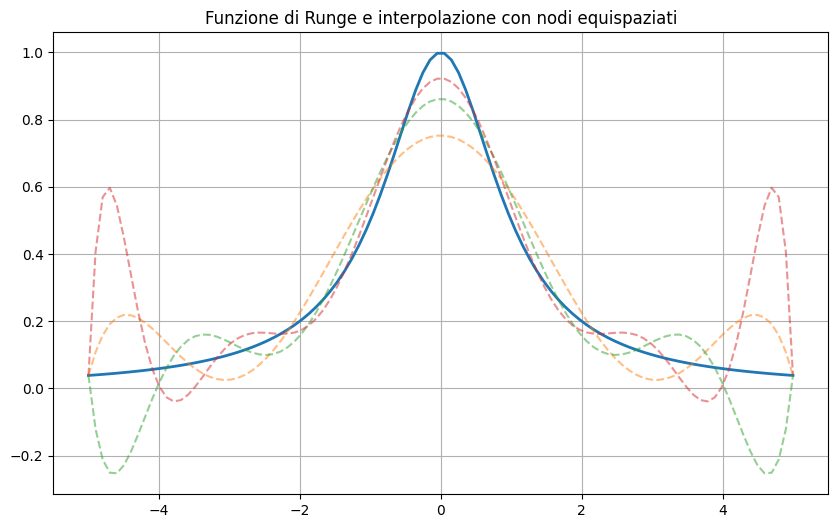

In [112]:
num_intervalli = [7, 9, 11]

plt.figure(figsize = (10,6))
plt.plot(x_grid, f(x_grid), linewidth=2, label='f(x)')
plt.title("Funzione di Runge e interpolazione con nodi equispaziati")
plt.grid()

# Costruzione delle interpolanti e rappresentazione
# TO DO...
for i in num_intervalli:
 x_nodi=np.linspace(a,b,i+1)
 y_nodi=f(x_nodi)
 p=polyfit(x_nodi,y_nodi,i)
 plt.plot(x_grid, interpolata(x_grid), '--', label = '$\\Pi_{%d}$f(x)' %n, alpha = 0.5)




<mark>**Domanda**</mark></br>
Che cosa sta succedendo all'aumentare di $n$? Perchè osserviamo queste oscillazioni? Discutere quello che è anche noto come **fenomeno di Runge**.

<mark>**Esercizio 1.3**</mark></br>
Si ripeta il punto precedente, utilizzando questa volta i nodi di Chebyshev. Si rammenta che, scelto $n$, sull'intervallo $\hat{I}=[-1,1]$, essi sono dati da
</br></br>
\begin{equation*}
\hat{x}_{i}=-\cos\left(\frac{\pi i}{n}\right),
\end{equation*}
</br>
dove $i=0,\dots,n$. I nodi possono essere trasferiti su un generico intervallo $[a,b]$ con la trasformazione
</br></br>
$$x_{i}=\frac{a+b}{2}+\frac{b-a}{2}\hat{x}_{i}.$$
</br>

In [113]:
def nodi_Chebyshev(a, b, n):
  """
  Calcolo degli n+1 nodi di Chebyshev sull'intervallo [a,b]
  Input:
  a: estremo sinistro dell'intervallo
  b: estremo destro dell'intervallo
  n: numero di intervalli (n+1 nodi)
  Output:
  x: nodi di Chebyshev
  """
  int=np.arange(0,n+1)
  x_i=-np.cos(np.pi*int/n)
  x=(a+b)/2+(b-a)/2*x_i


  return x


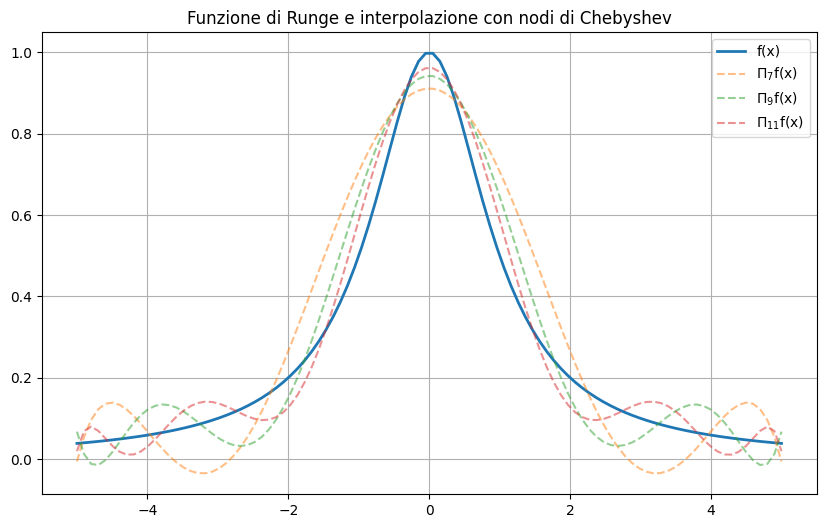

In [114]:
num_intervalli = [7, 9, 11]

plt.figure(figsize = (10,6))
plt.plot(x_grid, f(x_grid), linewidth=2, label='f(x)')
plt.title("Funzione di Runge e interpolazione con nodi di Chebyshev")
plt.grid()

# Costruzione delle interpolanti e rappresentazione
# TO DO...copia e incolla da esercizio precedente
for i in num_intervalli:
 x_nodi=nodi_Chebyshev(a,b,i+1)
 y_nodi=f(x_nodi)
 p=polyfit(x_nodi,y_nodi,i)
 plt.plot(x_grid, interpolata(x_grid), '--', label = '$\\Pi_{%d}$f(x)' %i, alpha = 0.5)


plt.legend()
plt.show()

In presenza di nodi equispaziati, l'interpolazione polinomiale può soffrire problemi di stabilità e convergenza. Due possibili soluzioni sono date da:

*   Nodi di interpolazione non equispaziati
*   Interpolazione composita (spline) -> la vediamo applicata all'esercizio 2



## **Esercizio 2: Interpolazione per l'approsimazione di dati**
Nella tabella qui sotto riportata vengono elencati i risultati di un
esperimento eseguito per individuare il legame tra lo *sforzo* $\sigma$ e la relativa *deformazione* $\varepsilon$.
</br></br>
\begin{equation}
\begin{matrix}
\text{test}\ & \sigma \ [{\rm MPa}] & \varepsilon [\text{cm}/\text{cm}]\\
    1 & 0.00 & 0.00 \\
    2 & 0.06 & 0.08 \\
    3 & 0.14 & 0.14 \\
    4 & 0.25 & 0.20 \\
    5 & 0.31 & 0.23 \\
    6 & 0.47 & 0.25 \\
    7 & 0.60 & 0.28 \\
    8 & 0.70 & 0.29 \\
  \end{matrix}
\end{equation}
</br>
A partire da questi dati (utilizzando opportune tecniche di interpolazione e approssimazione) si vuole stimare la deformazione $ɛ$ in corrispondenza dei valori di sforzo per cui non si ha a disposizione un dato sperimentale.


<mark>**Esercizio 2.1: rappresentazione grafica dei dati**</mark></br>
Rappresentare i dati graficamente.

In [115]:
# sigma ed epsilon
sigma = [0.00, 0.06, 0.14, 0.25, 0.31, 0.47, 0.60, 0.70]
epsilon = [0.00, 0.08, 0.14, 0.20, 0.23, 0.25, 0.28, 0.29]

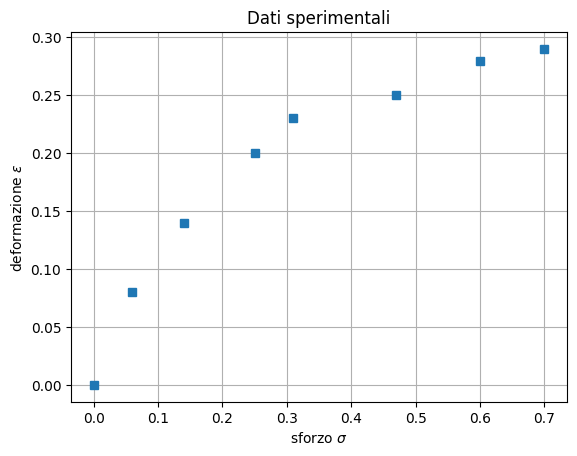

In [116]:
# Rappresentare i dati in un grafico sforzo vs deformazione
plt.figure()
plt.plot(sigma, epsilon, 's')
plt.xlabel("sforzo $\\sigma$")
plt.ylabel("deformazione $\\epsilon$")
plt.title("Dati sperimentali")
plt.grid()
plt.show()

<mark>**Esercizio 2.2: interpolazione polinomiale**</mark></br>
Calcolare l'interpolante polinomiale di Lagrange, quindi confrontarla con i dati sperimentali.

**Nota**: Si rammenti che un polinomio di Lagrange interpolante $n$ dati ha grado $n-1$.

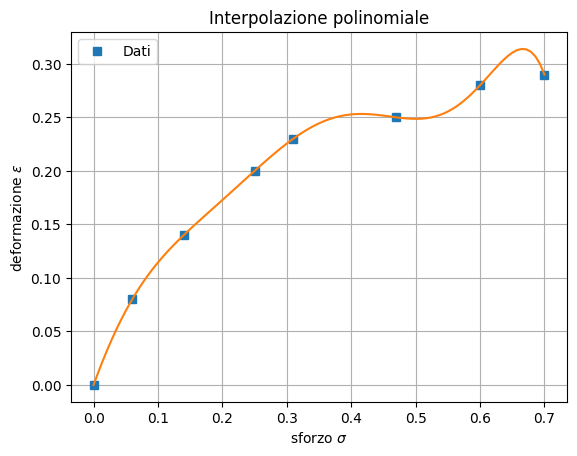

In [117]:
# Interpolazione di Lagrange e rappresentazione grafica
p=polyfit(sigma,epsilon,len(sigma)-1)

x_grid=np.linspace(min(sigma),max(sigma),100)

plt.figure()
plt.plot(sigma, epsilon, 's', label='Dati')
plt.plot(x_grid,interpolata(x_grid))
plt.xlabel("sforzo $\\sigma$")
plt.ylabel("deformazione $\\varepsilon$")
plt.title("Interpolazione polinomiale")
plt.legend()
plt.grid()

<mark>**Esercizio 2.3: spline lineare**</mark></br>
Confrontare i dati sperimentali con la loro interpolante lineare a tratti (spline lineare). Si sfrutti la funzione $\texttt{interp}$ della libreria $\texttt{numpy}$.

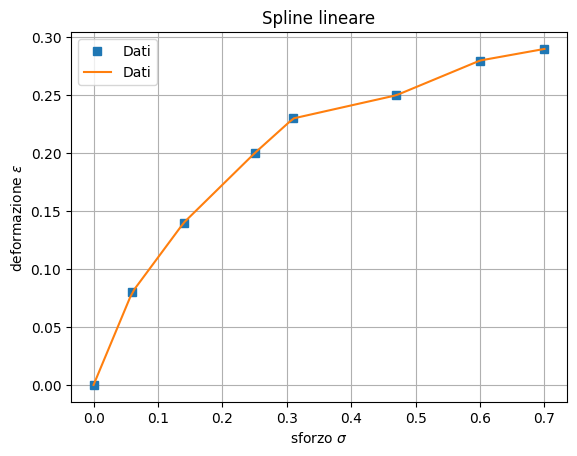

In [118]:
from numpy import interp


# Interpolazione composita (spline lineare) e rappresentazione
splinelineare=  lambda x: interp(x,sigma,epsilon)
plt.figure()
plt.plot(sigma, epsilon, 's', label='Dati')
plt.plot(x_grid, splinelineare(x_grid), '-', label='Dati')
plt.xlabel("sforzo $\\sigma$")
plt.ylabel("deformazione $\\varepsilon$")
plt.title("Spline lineare")
plt.legend()
plt.grid()

<mark>**Esercizio 2.4: spline cubica**</mark></br>
Confrontare i dati sperimentali con la loro interpolante cubica a tratti (spline cubica). Si sfrutti la classe $\texttt{CubicSpline}$ presente nel modulo $\texttt{scipy.interpolate}$.

In [119]:
from scipy.interpolate import CubicSpline
help(CubicSpline)

Help on class CubicSpline in module scipy.interpolate._cubic:

class CubicSpline(CubicHermiteSpline)
 |  CubicSpline(x, y, axis=0, bc_type='not-a-knot', extrapolate=None)
 |
 |  Piecewise cubic interpolator to fit values (C2 smooth).
 |
 |  Interpolate data with a piecewise cubic polynomial which is twice
 |  continuously differentiable [1]_. The result is represented as a `PPoly`
 |  instance with breakpoints matching the given data.
 |
 |  Parameters
 |  ----------
 |  x : array_like, shape (n,)
 |      1-D array containing values of the independent variable.
 |      Values must be real, finite and in strictly increasing order.
 |  y : array_like
 |      Array containing values of the dependent variable. It can have
 |      arbitrary number of dimensions, but the length along ``axis``
 |      (see below) must match the length of ``x``. Values must be finite.
 |  axis : int, optional
 |      Axis along which `y` is assumed to be varying. Meaning that for
 |      ``x[i]`` the correspon

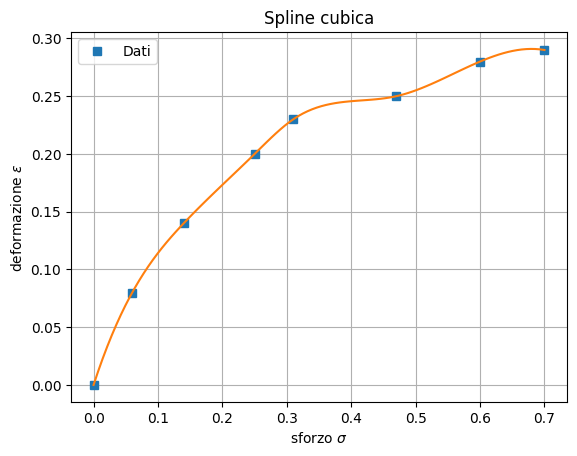

In [120]:
from scipy.interpolate import CubicSpline

splinecubica = CubicSpline(sigma,epsilon)

# Interpolazione composita (spline cubica) e rappresentazione grafica
plt.figure()
plt.plot(sigma, epsilon, 's', label='Dati')
plt.plot(x_grid,splinecubica(x_grid))
plt.xlabel("sforzo $\\sigma$")
plt.ylabel("deformazione $\\varepsilon$")
plt.title("Spline cubica")
plt.legend()
plt.grid()

<mark>**Esercizio 2.5: approssimazione nel senso dei minimi quadrati**</mark></br>

Dati $n+1$ punti distinti $(x_i, y_i)$, l'approssimazione ai minimi quadrati cerca il polinomio $\hat{p}$ di grado $1<m<n$ che minimizza la distanza dai dati, ovvero tale che:

\begin{equation}
\sum_{i=0}^{n} (y_i - \hat{p}(x_i))^2 \le \sum_{i=0}^{n} (y_i - p_m(x_i))^2
\end{equation}

Confrontare i dati sperimentali con il corrispondente polinomio di grado 4 che approssima i dati nel senso dei minimi quadrati. Si sfruttino nuovamente le funzioni $\texttt{polyfit}$ e $\texttt{polyval}$ di $\texttt{numpy}$, facendo attenzione all'argomento $\texttt{deg}$.

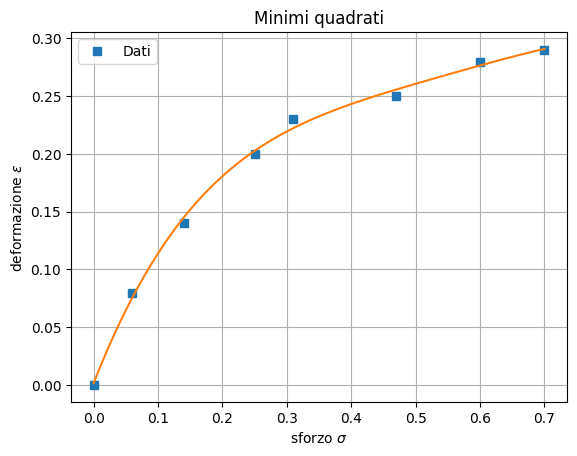

In [121]:
# Approssimazione ai minimi quadrati e rappresentazione grafica
deg=4
p=polyfit(sigma,epsilon,deg)


plt.figure()
plt.plot(sigma, epsilon, 's', label='Dati')
plt.plot(x_grid,interpolata(x_grid))
plt.xlabel("sforzo $\\sigma$")
plt.ylabel("deformazione $\\varepsilon$")
plt.title("Minimi quadrati")
plt.legend()
plt.grid()

<mark>**Esercizio 2.6: confronto globale**</mark></br>

Confrontare, in un unico grafico, i dati sperimentali con tutte le interpolanti e approssimanti. Si commentino i risultati.

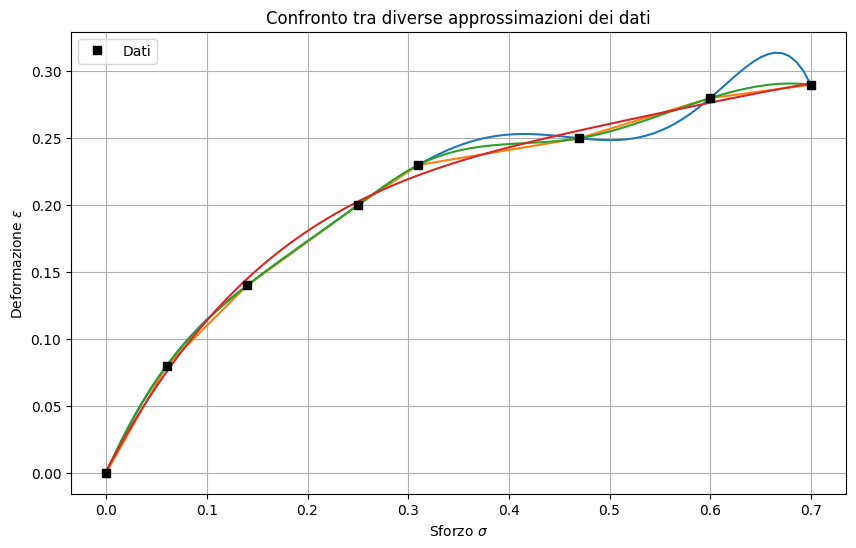

In [122]:
# Punti di valutazione
# x_grid (eventualmente ridefinire)

# Confronto
plt.figure(figsize=(10,6))

# Interpolante di Lagrange
p=polyfit(sigma,epsilon,len(epsilon)-1)
plt.plot(x_grid,interpolata(x_grid))
# Spline lineare
plt.plot(x_grid,splinelineare(x_grid))
# Spline cubica
plt.plot(x_grid,splinecubica(x_grid))
# Minimi quadrati
deg=4
p=polyfit(sigma,epsilon,deg)
plt.plot(x_grid,interpolata(x_grid))
# Dati
plt.plot(sigma, epsilon, 'ks', label='Dati')

plt.legend()
plt.title("Confronto tra diverse approssimazioni dei dati")
plt.grid()
plt.xlabel("Sforzo $\\sigma$")
plt.ylabel("Deformazione $\\varepsilon$")
plt.show()

<mark>**Esercizio 2.7: confronto approssimazioni in extra points**</mark></br>

Confrontare le approssimazioni proposte dalle tre interpolanti  e dell'approssimazione ai minimi quadrati quando $\sigma=0.4 \text{ MPa}$ e $\sigma=0.75 \text{ MPa}$, si commentino i risultati ottenuti.

approssimazioni con interpolata di lagrangde
[0.25274726 0.08096255]
approssimazioni con spline lineare
[0.24125 0.29   ]
approssimazioni con spline cubica
[0.24565586 0.27810806]
approssimazioni con minimi quadrat
[0.24318326 0.29641622]


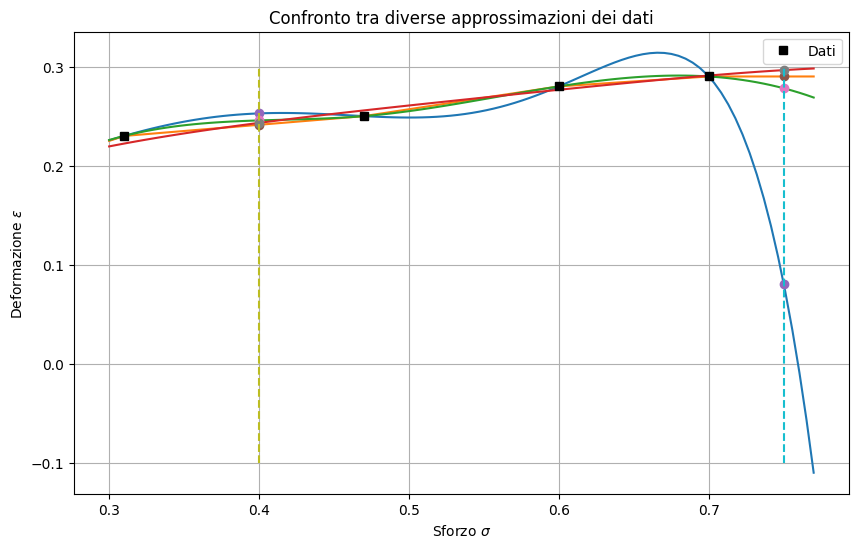

In [123]:
plt.figure(figsize=(10,6))

x_grid=np.linspace(0.3,0.77,100)

# Interpolante di Lagrange
p=polyfit(sigma,epsilon,len(epsilon)-1)
plt.plot(x_grid,interpolata(x_grid))
# Spline lineare
plt.plot(x_grid,splinelineare(x_grid))
# Spline cubica
plt.plot(x_grid,splinecubica(x_grid))
# Minimi quadrati
deg=4
p=polyfit(sigma,epsilon,deg)
plt.plot(x_grid,interpolata(x_grid))
# Dati
plt.plot(sigma[4:], epsilon[4:], 'ks', label='Dati')

# Stima dei valori
x=np.array([0.4,0.75])
p=polyfit(sigma,epsilon,len(epsilon)-1)
lagrange=interpolata(x) 
print("approssimazioni con interpolata di lagrangde")
print(lagrange)
# Spline lineare
spl=splinelineare(x)
print("approssimazioni con spline lineare")
print(spl)
# Spline cubica
spc=splinecubica(x)
print("approssimazioni con spline cubica")
print(spc)
# Minimi quadrati
deg=4
p=polyfit(sigma,epsilon,deg)
mq=interpolata(x)
print("approssimazioni con minimi quadrat")
print(mq)

plt.plot(x,lagrange,'o')
plt.plot(x,spl,'o')
plt.plot(x,spc,'o')
plt.plot(x,mq,'o')

y_grid=(np.linspace(-0.1,0.3,100))
plt.plot(0.4*np.ones(len(y_grid)),y_grid,'--')
plt.plot(0.75*np.ones(len(y_grid)),y_grid,'--')
plt.legend()
plt.title("Confronto tra diverse approssimazioni dei dati")
plt.grid()
plt.xlabel("Sforzo $\\sigma$")
plt.ylabel("Deformazione $\\varepsilon$")
plt.show()

In [124]:
# Confronto grafico

## **Esercizi per casa**

<mark>**Esercizio 3**</mark></br>
Si consideri la funzione $f(x) = x \sin(x)$.

  1.  Si disegni  il grafico della funzione $f(x)$ nell'intervallo $[-2,6]$.
  2. Si costruiscano i polinomi interpolanti di Lagrange $\Pi_{n}f$ di grado $n=2,\,4,\,6$ relativi ad una distribuzione di nodi  equispaziati.
  3. Si rappresenti graficamente l'andamento dell'errore
$\varepsilon(x)=|f(x)-\Pi_{n}f(x)|$ e si calcoli la norma infinito:

$$
\parallel \varepsilon(x)\parallel_{\infty}=\max_{x\in[-2,6]}|f(x)-\Pi_{n}f(x)|.
$$

Commentare i risultati.

In [125]:
help(plt.plot)

Help on function plot in module matplotlib.pyplot:

plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'
    Plot y versus x as lines and/or markers.

    Call signatures::

        plot([x], y, [fmt], *, data=None, **kwargs)
        plot([x], y, [fmt], [x2], y2, [fmt2], ..., **kwargs)

    The coordinates of the points or line nodes are given by *x*, *y*.

    The optional parameter *fmt* is a convenient way for defining basic
    formatting like color, marker and linestyle. It's a shortcut string
    notation described in the *Notes* section below.

    >>> plot(x, y)        # plot x and y using default line style and color
    >>> plot(x, y, 'bo')  # plot x and y using blue circle markers
    >>> plot(y)           # plot y using x as index array 0..N-1
    >>> plot(y, 'r+')     # ditto, but with red plusses

    You can use `.Line2D` properties as keyword arguments for more
    control on the appearance. Line pro

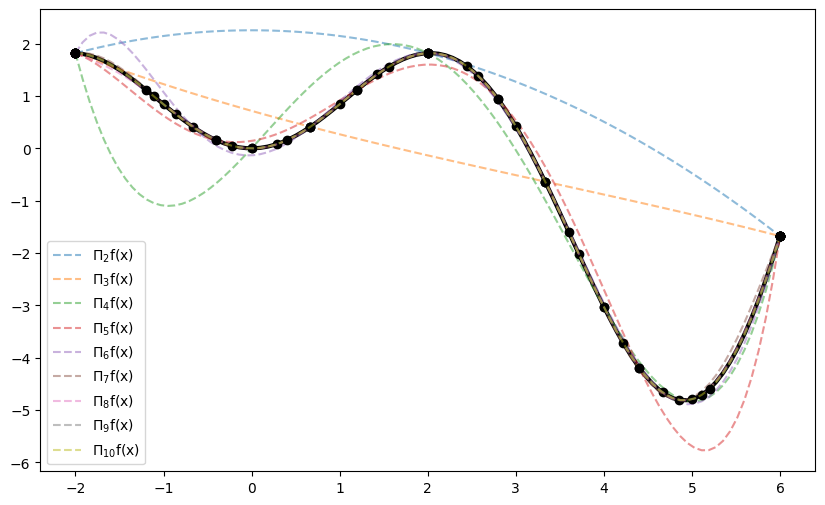

/tmp/ipykernel_41834/2034133841.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


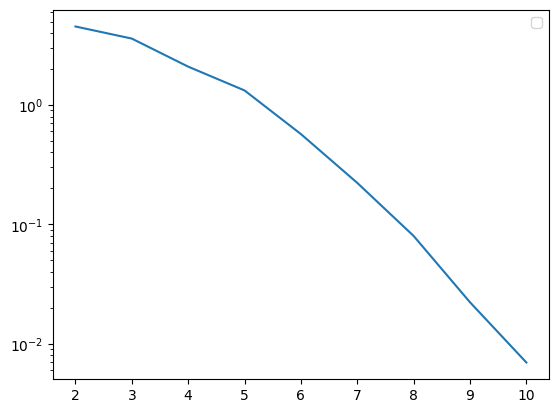

In [130]:
plt.figure(figsize=(10,6))
f= lambda x: x*np.sin(x)
a=-2
b=6
degs=range(2,11,1)
x_grid=np.linspace(a,b,100)
epsilon=[]
plt.plot(x_grid,f(x_grid),'k',linewidth=3)
#for i in range(2,7,2):
for i in degs:
    x_nodi=np.linspace(a,b,i+1)
    y_nodi=f(x_nodi)
    p=polyfit(x_nodi,y_nodi,i)
    inter =lambda x: polyval(p,x)
    plt.plot(x_grid,inter(x_grid),'--' ,label = '$\\Pi_{%d}$f(x)' %i, alpha = 0.5)
    plt.plot(x_nodi,y_nodi,'ko')
    epsilon.append(max(abs(f(x_grid)-inter(x_grid))))
#print(epsilon)
plt.legend()
plt.show()
plt.figure()
plt.semilogy(degs,epsilon)
plt.legend()
plt.show()